In [1]:
from JC_functions import *
from JC_momenst import *
from embedder import *
import os
import pandas as pd
import scipy
import numpy as np
import scipy.io
from sklearn.preprocessing import LabelEncoder
from JC_momenst import *
from JC_functions import *
from embedder import *

RAW_PATH = os.path.join(os.getcwd(), "data", "Flavia.mat")
LABELS_PATH = os.path.join(os.getcwd(), "data", "labels.xlsx")
A_raw = scipy.io.loadmat(RAW_PATH)
leaves = A_raw['Flavia_rotated_clean']
df = pd.read_excel(LABELS_PATH)
df = df.dropna()
df = df.sort_values(df.columns[1])
labels = df.iloc[:, 2].to_numpy()
labels = np.asarray(labels).astype(int)

N, d, c = leaves.shape

/users/glongari/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import os

X_path = "X.npy"

if not os.path.exists(X_path):
    moments_list = invariant_n_moments(12)
    #moments_list.append([(0,0,0), (0,2,2), (1,1,0), (0,1,1), (2,2,0), (3,3,0), (4,4,0), (1,0,0), (0,2,0), (0,0,2), (0,1,2), (0,3,0), (0,0,3), (0,1,3), (0,2,3), (0,3,3), (1,2,1), (0,0,4), (3,1,1), (0,3,1), (0,5,1), (3,2,1), (2,3,1)])
    complex_leaves = np.array([Normalize(shape_to_complex(reparametrize_by_arc_length(leaves[i], 50, False)[1][:-1])) for i in range(N)])

    feature_dicts = [all_moments(remove_duplicate_vertices(leaf), moments_list) for leaf in complex_leaves]

    feature_names = list(feature_dicts[0].keys())
    X_real = np.array([
        [fd[name].real if np.iscomplexobj(fd[name]) else fd[name]
         for name in feature_names]
        for fd in feature_dicts
    ], dtype=float)

    X_imag = np.array([
        [fd[name].imag if np.iscomplexobj(fd[name]) else 0.0
         for name in feature_names]
        for fd in feature_dicts
    ], dtype=float)

    X = np.concatenate([X_real, X_imag], axis=1)
    np.save(X_path, X)
    print(f"X computed and saved to '{X_path}'")
else:
    X = np.load(X_path)
    print(f"X loaded from '{X_path}'")

X loaded from 'X.npy'


### WITH THE 13

In [3]:
import os

X_path = "X_13.npy"

if not os.path.exists(X_path):
    moments_list = invariant_n_moments(12)
    complex_leaves = np.array([Normalize(shape_to_complex(reparametrize_by_arc_length(leaves[i], 400, False)[1][:-1])) for i in range(N)])

    feature_dicts = [features_13(remove_duplicate_vertices(leaf)) for leaf in complex_leaves]

    feature_names = list(feature_dicts[0].keys())
    X_real = np.array([
        [fd[name].real if np.iscomplexobj(fd[name]) else fd[name]
         for name in feature_names]
        for fd in feature_dicts
    ], dtype=float)

    X_imag = np.array([
        [fd[name].imag if np.iscomplexobj(fd[name]) else 0.0
         for name in feature_names]
        for fd in feature_dicts
    ], dtype=float)

    X = np.concatenate([X_real, X_imag], axis=1)
    np.save(X_path, X)
    print(f"X computed and saved to '{X_path}'")
else:
    X = np.load(X_path)
    print(f"X loaded from '{X_path}'")

X computed and saved to 'X_13.npy'


Running randomized hyperparameter search (60 iterations × 5-fold CV)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END colsample_bylevel=0.6, colsample_bytree=0.5, gamma=0.5, learning_rate=0.2, max_depth=8, min_child_weight=3, n_estimators=300, reg_alpha=0.01, reg_lambda=5.0, subsample=0.9; total time=   1.5s
[CV] END colsample_bylevel=0.6, colsample_bytree=0.5, gamma=0.5, learning_rate=0.2, max_depth=8, min_child_weight=3, n_estimators=300, reg_alpha=0.01, reg_lambda=5.0, subsample=0.9; total time=   2.5s
[CV] END colsample_bylevel=0.6, colsample_bytree=0.5, gamma=0.5, learning_rate=0.2, max_depth=8, min_child_weight=3, n_estimators=300, reg_alpha=0.01, reg_lambda=5.0, subsample=0.9; total time=   2.5s
[CV] END colsample_bylevel=0.6, colsample_bytree=0.5, gamma=0.5, learning_rate=0.2, max_depth=8, min_child_weight=3, n_estimators=300, reg_alpha=0.01, reg_lambda=5.0, subsample=0.9; total time=   2.6s
[CV] END colsample_bylevel=0.8, colsample_bytree=0.5, gamma=0.

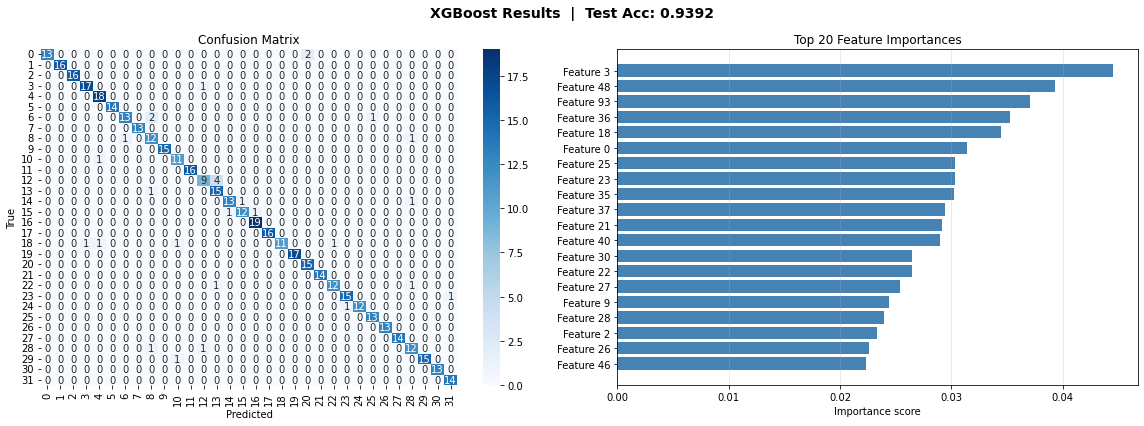

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
import xgboost as xgb

# ── Preprocessing ─────────────────────────────────────────────────────────────
# XGBoost doesn't need scaling, but we keep it for consistency with your pipeline
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# XGBoost requires integer labels starting from 0
le = LabelEncoder()
y_encoded = le.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

# ── Hyperparameter search space ───────────────────────────────────────────────
param_dist = {
    "n_estimators":      [300, 500, 700, 1000],
    "max_depth":         [3, 4, 5, 6, 7, 8],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "subsample":         [0.6, 0.7, 0.8, 0.9, 1.0],      # row sampling
    "colsample_bytree":  [0.5, 0.6, 0.7, 0.8, 1.0],      # feature sampling per tree
    "colsample_bylevel": [0.6, 0.8, 1.0],                 # feature sampling per level
    "min_child_weight":  [1, 3, 5, 7],                    # controls overfitting
    "gamma":             [0, 0.1, 0.3, 0.5],              # min loss reduction to split
    "reg_alpha":         [0, 0.01, 0.1, 1.0],             # L1 regularisation
    "reg_lambda":        [0.5, 1.0, 2.0, 5.0],            # L2 regularisation
}

base_xgb = xgb.XGBClassifier(
    objective="multi:softmax",       # change to "binary:logistic" if 2 classes
    eval_metric="mlogloss",
    tree_method="hist",              # fast histogram method (GPU-ready)
    device="cuda" if xgb.get_config().get("use_rmm", False) else "cpu",
    random_state=42,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=60,                       # increase for better coverage (costs time)
    scoring="accuracy",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

print("Running randomized hyperparameter search (60 iterations × 5-fold CV)...")
search.fit(X_train, y_train)

print(f"\nBest CV accuracy : {search.best_score_:.4f}")
print(f"Best params      : {search.best_params_}")

# ── Final evaluation ──────────────────────────────────────────────────────────
best_model = search.best_estimator_
y_pred     = best_model.predict(X_test)
acc        = accuracy_score(y_test, y_pred)

print(f"\nTest accuracy : {acc:.4f}  (your baseline: 0.90)")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"XGBoost Results  |  Test Acc: {acc:.4f}", fontsize=14, fontweight="bold")

# — Confusion matrix —
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# — Feature importance (top 20) —
importance = best_model.feature_importances_
top_n      = min(20, len(importance))
top_idx    = np.argsort(importance)[-top_n:][::-1]
axes[1].barh(range(top_n), importance[top_idx], align="center", color="steelblue")
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([f"Feature {i}" for i in top_idx])
axes[1].invert_yaxis()
axes[1].set_title(f"Top {top_n} Feature Importances")
axes[1].set_xlabel("Importance score")
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("xgboost_results.png", dpi=150, bbox_inches="tight")
plt.show()

Test accuracy: 0.9455

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.94      0.94      0.94        16
           2       1.00      1.00      1.00        16
           3       0.94      0.94      0.94        18
           4       0.95      1.00      0.97        18
           5       1.00      1.00      1.00        14
           6       0.93      0.88      0.90        16
           7       1.00      1.00      1.00        13
           8       0.85      0.79      0.81        14
           9       1.00      1.00      1.00        15
          10       0.92      1.00      0.96        12
          11       1.00      1.00      1.00        16
          12       0.83      0.77      0.80        13
          13       0.81      0.81      0.81        16
          14       0.75      0.80      0.77        15
          15       0.92      0.86      0.89        14
          16       1.00      1.00  

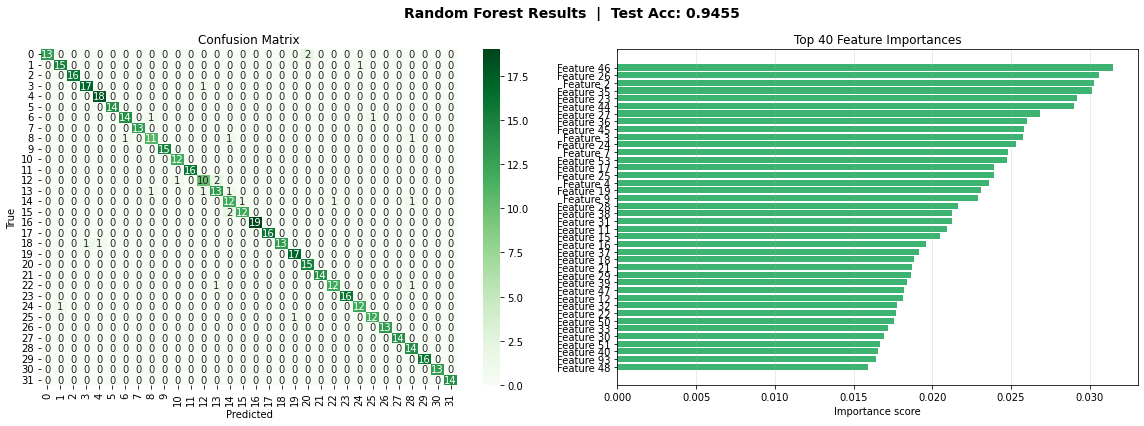

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {acc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Random Forest Results  |  Test Acc: {acc:.4f}", fontsize=14, fontweight="bold")

# — Confusion matrix —
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=np.unique(labels), yticklabels=np.unique(labels),
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# — Feature importance (top 20) —
importance = rf.feature_importances_
top_n      = min(40, len(importance))
top_idx    = np.argsort(importance)[-top_n:][::-1]
axes[1].barh(range(top_n), importance[top_idx], align="center", color="mediumseagreen")
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([f"Feature {i}" for i in top_idx])
axes[1].invert_yaxis()
axes[1].set_title(f"Top {top_n} Feature Importances")
axes[1].set_xlabel("Importance score")
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("random_forest_results.png", dpi=150, bbox_inches="tight")
plt.show()

Input dim: 104  |  Classes: 32  |  Samples: 1907
  Class 0: 59 samples (3.1%)
  Class 1: 63 samples (3.3%)
  Class 2: 65 samples (3.4%)
  Class 3: 72 samples (3.8%)
  Class 4: 73 samples (3.8%)
  Class 5: 56 samples (2.9%)
  Class 6: 62 samples (3.3%)
  Class 7: 52 samples (2.7%)
  Class 8: 55 samples (2.9%)
  Class 9: 59 samples (3.1%)
  Class 10: 50 samples (2.6%)
  Class 11: 63 samples (3.3%)
  Class 12: 52 samples (2.7%)
  Class 13: 65 samples (3.4%)
  Class 14: 60 samples (3.1%)
  Class 15: 56 samples (2.9%)
  Class 16: 77 samples (4.0%)
  Class 17: 62 samples (3.3%)
  Class 18: 61 samples (3.2%)
  Class 19: 66 samples (3.5%)
  Class 20: 60 samples (3.1%)
  Class 21: 55 samples (2.9%)
  Class 22: 55 samples (2.9%)
  Class 23: 65 samples (3.4%)
  Class 24: 54 samples (2.8%)
  Class 25: 52 samples (2.7%)
  Class 26: 53 samples (2.8%)
  Class 27: 55 samples (2.9%)
  Class 28: 57 samples (3.0%)
  Class 29: 64 samples (3.4%)
  Class 30: 53 samples (2.8%)
  Class 31: 56 samples (2.9%)
I

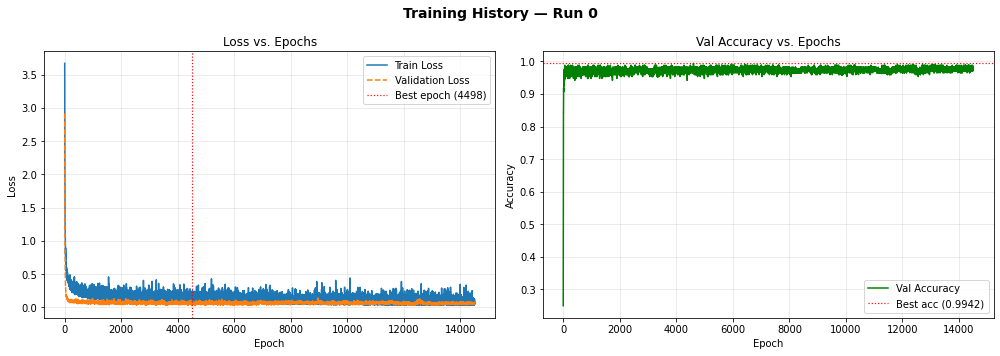

  RUN 2 / 5  (seed=1)
  [Run 1] Epoch 00001 | Train Loss: 3.6753 | Val Loss: 2.9179 | Val Acc: 0.3256 | LR: 1.00e-03
  [Run 1] Epoch 01000 | Train Loss: 0.2306 | Val Loss: 0.1359 | Val Acc: 0.9477 | LR: 1.00e-03
  [Run 1] Epoch 02000 | Train Loss: 0.1961 | Val Loss: 0.0965 | Val Acc: 0.9535 | LR: 1.00e-03
  [Run 1] Epoch 03000 | Train Loss: 0.1595 | Val Loss: 0.1095 | Val Acc: 0.9651 | LR: 1.00e-03
  [Run 1] Epoch 04000 | Train Loss: 0.1054 | Val Loss: 0.1501 | Val Acc: 0.9477 | LR: 1.00e-03
  [Run 1] Epoch 05000 | Train Loss: 0.0852 | Val Loss: 0.1248 | Val Acc: 0.9593 | LR: 5.00e-04
  [Run 1] Epoch 06000 | Train Loss: 0.1378 | Val Loss: 0.1363 | Val Acc: 0.9709 | LR: 5.00e-04
  [Run 1] Epoch 07000 | Train Loss: 0.1293 | Val Loss: 0.1140 | Val Acc: 0.9360 | LR: 5.00e-04
  [Run 1] Epoch 08000 | Train Loss: 0.1081 | Val Loss: 0.1070 | Val Acc: 0.9651 | LR: 2.50e-04
  [Run 1] Epoch 09000 | Train Loss: 0.0652 | Val Loss: 0.1275 | Val Acc: 0.9709 | LR: 2.50e-04
  [Run 1] Epoch 10000 | Trai

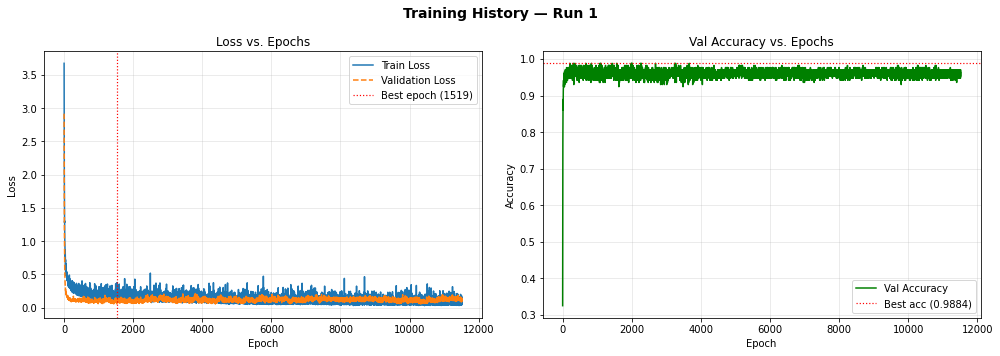

  RUN 3 / 5  (seed=2)
  [Run 2] Epoch 00001 | Train Loss: 3.5744 | Val Loss: 2.8055 | Val Acc: 0.3198 | LR: 1.00e-03
  [Run 2] Epoch 01000 | Train Loss: 0.1897 | Val Loss: 0.1442 | Val Acc: 0.9709 | LR: 1.00e-03
  [Run 2] Epoch 02000 | Train Loss: 0.1812 | Val Loss: 0.1297 | Val Acc: 0.9651 | LR: 1.00e-03
  [Run 2] Epoch 03000 | Train Loss: 0.1522 | Val Loss: 0.1204 | Val Acc: 0.9709 | LR: 1.00e-03
  [Run 2] Epoch 04000 | Train Loss: 0.1065 | Val Loss: 0.1235 | Val Acc: 0.9709 | LR: 1.00e-03
  [Run 2] Epoch 05000 | Train Loss: 0.1569 | Val Loss: 0.1099 | Val Acc: 0.9767 | LR: 1.00e-03
  [Run 2] Epoch 06000 | Train Loss: 0.1795 | Val Loss: 0.1104 | Val Acc: 0.9709 | LR: 1.00e-03
  [Run 2] Epoch 07000 | Train Loss: 0.1026 | Val Loss: 0.1228 | Val Acc: 0.9709 | LR: 1.00e-03
  [Run 2] Epoch 08000 | Train Loss: 0.1509 | Val Loss: 0.1064 | Val Acc: 0.9767 | LR: 1.00e-03
  [Run 2] Epoch 09000 | Train Loss: 0.1216 | Val Loss: 0.1053 | Val Acc: 0.9709 | LR: 1.00e-03
  [Run 2] Epoch 10000 | Trai

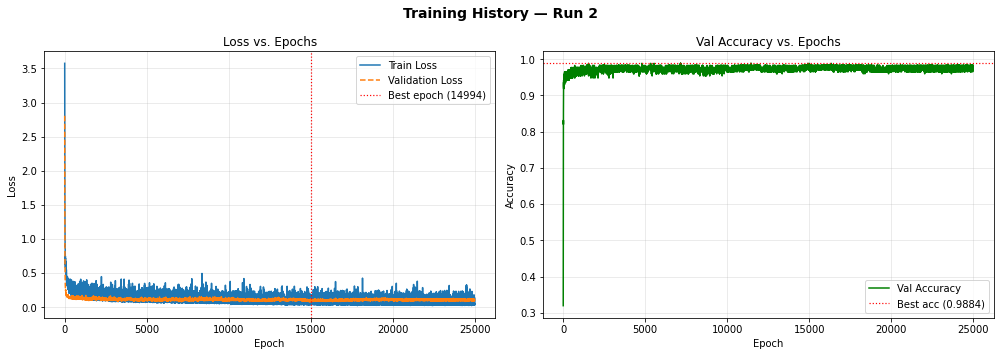

  RUN 4 / 5  (seed=3)
  [Run 3] Epoch 00001 | Train Loss: 3.7155 | Val Loss: 2.8193 | Val Acc: 0.2907 | LR: 1.00e-03
  [Run 3] Epoch 01000 | Train Loss: 0.2081 | Val Loss: 0.1689 | Val Acc: 0.9477 | LR: 1.00e-03
  [Run 3] Epoch 02000 | Train Loss: 0.2249 | Val Loss: 0.1805 | Val Acc: 0.9477 | LR: 1.00e-03
  [Run 3] Epoch 03000 | Train Loss: 0.1516 | Val Loss: 0.1807 | Val Acc: 0.9593 | LR: 1.00e-03
  [Run 3] Epoch 04000 | Train Loss: 0.1543 | Val Loss: 0.2081 | Val Acc: 0.9419 | LR: 1.00e-03
  [Run 3] Epoch 05000 | Train Loss: 0.0632 | Val Loss: 0.2137 | Val Acc: 0.9477 | LR: 5.00e-04
  [Run 3] Epoch 06000 | Train Loss: 0.0694 | Val Loss: 0.1961 | Val Acc: 0.9593 | LR: 5.00e-04
  [Run 3] Epoch 07000 | Train Loss: 0.0536 | Val Loss: 0.2094 | Val Acc: 0.9419 | LR: 5.00e-04
  [Run 3] Epoch 08000 | Train Loss: 0.1730 | Val Loss: 0.1948 | Val Acc: 0.9477 | LR: 2.50e-04
  [Run 3] Epoch 09000 | Train Loss: 0.0878 | Val Loss: 0.1653 | Val Acc: 0.9651 | LR: 2.50e-04
  [Run 3] Epoch 10000 | Trai

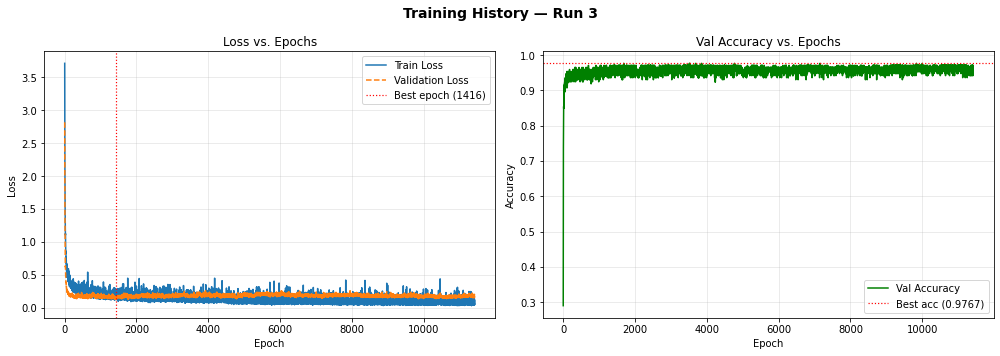

  RUN 5 / 5  (seed=4)
  [Run 4] Epoch 00001 | Train Loss: 3.9420 | Val Loss: 2.9437 | Val Acc: 0.2965 | LR: 1.00e-03
  [Run 4] Epoch 01000 | Train Loss: 0.1776 | Val Loss: 0.1005 | Val Acc: 0.9593 | LR: 1.00e-03
  [Run 4] Epoch 02000 | Train Loss: 0.1769 | Val Loss: 0.1176 | Val Acc: 0.9535 | LR: 1.00e-03
  [Run 4] Epoch 03000 | Train Loss: 0.1182 | Val Loss: 0.0824 | Val Acc: 0.9826 | LR: 1.00e-03
  [Run 4] Epoch 04000 | Train Loss: 0.1054 | Val Loss: 0.0897 | Val Acc: 0.9709 | LR: 1.00e-03
  [Run 4] Epoch 05000 | Train Loss: 0.0872 | Val Loss: 0.0839 | Val Acc: 0.9709 | LR: 1.00e-03
  [Run 4] Epoch 06000 | Train Loss: 0.0981 | Val Loss: 0.1141 | Val Acc: 0.9709 | LR: 1.00e-03
  [Run 4] Epoch 07000 | Train Loss: 0.0959 | Val Loss: 0.0919 | Val Acc: 0.9651 | LR: 1.00e-03
  [Run 4] Epoch 08000 | Train Loss: 0.1221 | Val Loss: 0.0755 | Val Acc: 0.9826 | LR: 1.00e-03
  [Run 4] Epoch 09000 | Train Loss: 0.1201 | Val Loss: 0.0890 | Val Acc: 0.9767 | LR: 5.00e-04
  [Run 4] Epoch 10000 | Trai

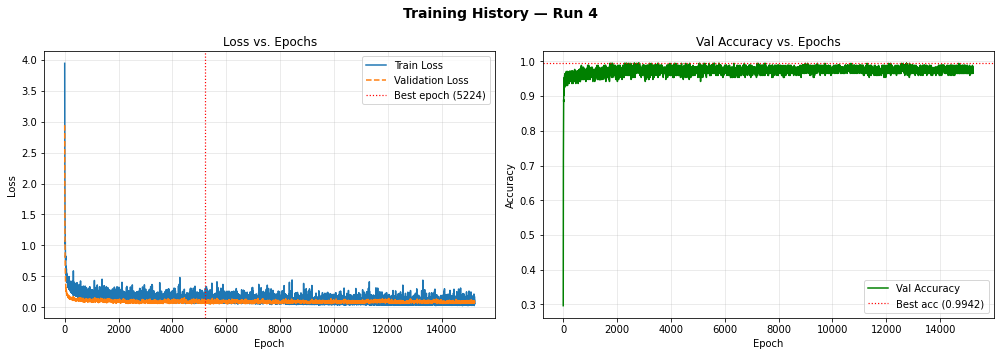


  CROSS-VALIDATION SUMMARY (5 runs)
  Run 0: Val Acc = 0.9942  |  Test Acc = 0.9476
  Run 1: Val Acc = 0.9884  |  Test Acc = 0.9215
  Run 2: Val Acc = 0.9884  |  Test Acc = 0.9738
  Run 3: Val Acc = 0.9767  |  Test Acc = 0.9529
  Run 4: Val Acc = 0.9942  |  Test Acc = 0.9529

  Val  Acc — mean: 0.9884  std: 0.0064
  Test Acc — mean: 0.9497  std: 0.0168


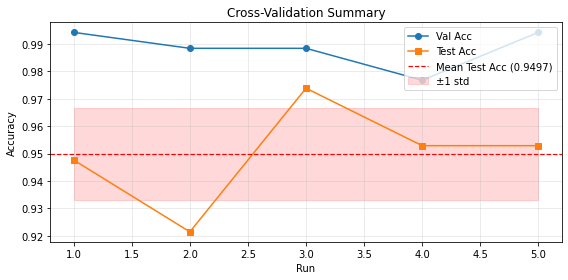

In [6]:
# Encode labels once upfront
le = LabelEncoder()
y = le.fit_transform(labels)

num_classes = len(np.unique(y))
input_dim   = X.shape[1]

# Sanity checks
assert not np.isnan(X).any(), "Data contains NaN values!"
assert not np.isinf(X).any(), "Data contains Inf values!"
print(f"Input dim: {input_dim}  |  Classes: {num_classes}  |  Samples: {len(y)}")
for cls, count in zip(*np.unique(y, return_counts=True)):
    print(f"  Class {le.inverse_transform([cls])[0]}: {count} samples ({100*count/len(y):.1f}%)")

# Run 5-fold repeated cross-validation
test_accs, val_accs = run_cross_validation(X, y, n_runs=5)

### Concatenating

In [7]:
import numpy as np

a = np.load('X.npy')
b = np.load('X_13.npy')

X = np.concatenate([a, b], axis=1)  # stack rows (more samples)

In [8]:
X_train, X_val, y_train, y_val = split_normalize(X, labels)

# Fix: encode string/object labels to integers
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val   = le.transform(y_val)


num_classes = len(np.unique(labels))
input_dim   = X_train.shape[1]
print(f"Input dim: {input_dim}  |  Classes: {num_classes}")

# Wrap MLP so the constructor uses the actual input_dim / num_classes
BoundMLP = lambda: MLP(input_dim=input_dim, num_classes=num_classes)

train_model(X_train, X_val, y_train, y_val, BoundMLP)

ValueError: too many values to unpack (expected 4)

### Claudio

In [8]:
import os

X_path = "X.npy"

if not os.path.exists(X_path):
    moments_list = invariant_n_moments(12)
    complex_leaves = np.array([Normalize(shape_to_complex(reparametrize_by_arc_length(leaves[i], 20, False)[1][:-1])) for i in range(N)])

    # all_moments returns a flat np.array of real values directly
    feature_arrays = [claude_moments(remove_duplicate_vertices(leaf), moments_list) for leaf in complex_leaves]

    X = np.array(feature_arrays, dtype=float)
    np.save(X_path, X)
    print(f"X computed and saved to '{X_path}'")
else:
    X = np.load(X_path)
    print(f"X loaded from '{X_path}'")

X loaded from 'X.npy'


In [9]:
import os
import scipy.io
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from JC_momenst import *
from JC_functions import *
from embedder import (
    split_normalize,
    MLP,
    main as train_model,
)

X_train, X_val, y_train, y_val = split_normalize(X, labels)

# Fix: encode string/object labels to integers
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val   = le.transform(y_val)


num_classes = len(np.unique(labels))
input_dim   = X_train.shape[1]
print(f"Input dim: {input_dim}  |  Classes: {num_classes}")

# Wrap MLP so the constructor uses the actual input_dim / num_classes
BoundMLP = lambda: MLP(input_dim=input_dim, num_classes=num_classes)

train_model(X_train, X_val, y_train, y_val, BoundMLP)

Input dim: 3003  |  Classes: 32
The device utilized is cpu
Epoch 001 | Train Loss: 81.3331 | Val Loss: 20.0565 | Val Acc: 0.0681 | Best Val Acc: 0.0681
Epoch 002 | Train Loss: 80.3787 | Val Loss: 20.0740 | Val Acc: 0.0681 | Best Val Acc: 0.0681
Epoch 003 | Train Loss: 79.3850 | Val Loss: 19.9291 | Val Acc: 0.0890 | Best Val Acc: 0.0890
Epoch 004 | Train Loss: 78.9253 | Val Loss: 19.9672 | Val Acc: 0.0785 | Best Val Acc: 0.0890
Epoch 005 | Train Loss: 78.7071 | Val Loss: 19.9066 | Val Acc: 0.0785 | Best Val Acc: 0.0890
Epoch 006 | Train Loss: 78.1527 | Val Loss: 19.9119 | Val Acc: 0.0838 | Best Val Acc: 0.0890
Epoch 007 | Train Loss: 77.1498 | Val Loss: 19.8456 | Val Acc: 0.0890 | Best Val Acc: 0.0890
Epoch 008 | Train Loss: 77.3542 | Val Loss: 19.7798 | Val Acc: 0.0681 | Best Val Acc: 0.0890
Epoch 009 | Train Loss: 77.0709 | Val Loss: 19.7350 | Val Acc: 0.0942 | Best Val Acc: 0.0942
Epoch 010 | Train Loss: 76.9738 | Val Loss: 19.8184 | Val Acc: 0.0733 | Best Val Acc: 0.0942
Epoch 011 |